Exploratory Data Analysis & Intro

Goal:
1.Investigate top-paying roles and skills in the data science industry.
2.Use Phyton to explore a real-live dataset on job postings.
3.For job-seekers:use these insights to help find the best job opportunities.

Final Deliverables:
-Create Jupyter Notebookss(showcasing core skills in Phyton)
-Create a summary page (via. README.md) capturing my findings.
-Share this project via GitHub & Linkedln.

Question to Answer
1. What are the most demanded skills for top 3 most popular data roles?
2.How are in-demand skills trending for Data Analysts?
3.How well do jobs and skills pay for Data Analyst?
4.What is the most optimal skill to learn for Data Analysts?

I am going to focus on US Data Analyst roles.

In [1]:
#Importing Libraries
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

#Loading the dataset
dataset=load_dataset('lukebarousse/data_jobs')
df=dataset['train'].to_pandas()

#Data Cleaning
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
df['job_skills']=df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [2]:
#Filtering for Data Analyst jobs in the US
df_DA_US=df[(df['job_title_short']=='Data Analyst') & (df['job_country']=='United States')]

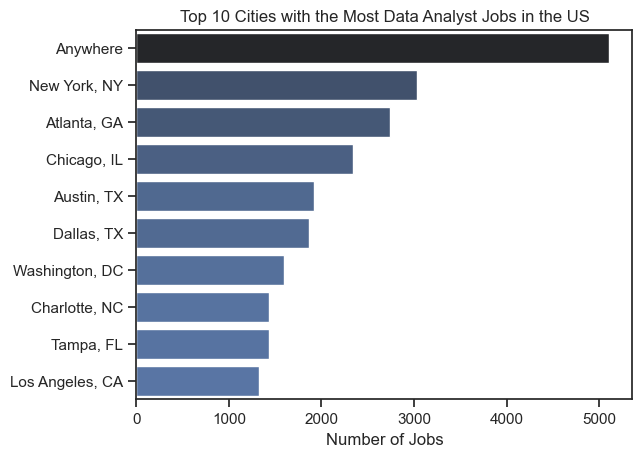

In [13]:
df_plot=df_DA_US['job_location'].value_counts().head(10).to_frame()
sns.set_theme(style='ticks')
sns.barplot(data=df_plot,x='count',y='job_location',hue='count',palette='dark:b_r',legend=False)
plt.title('Top 10 Cities with the Most Data Analyst Jobs in the US')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

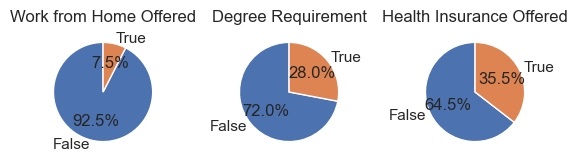

In [17]:
fig, ax = plt.subplots(1,3)

plt.subplots_adjust(wspace=0.5)
dict_column={'job_work_from_home':'Work from Home Offered','job_no_degree_mention':'Degree Requirement','job_health_insurance':'Health Insurance Offered'}

for i,(column,title) in enumerate(dict_column.items()):
    ax[i].pie(df_DA_US[column].value_counts(),labels=df_DA_US[column].value_counts().index,autopct='%1.1f%%',startangle=90)
    ax[i].set_title(title)

plt.show()

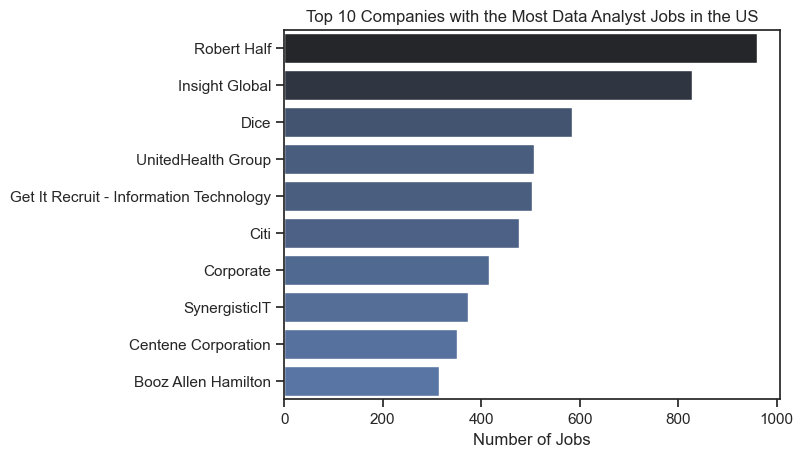

In [18]:
df_plot=df_DA_US['company_name'].value_counts().head(10).to_frame()
sns.set_theme(style='ticks')
sns.barplot(data=df_plot,x='count',y='company_name',hue='count',palette='dark:b_r',legend=False)
plt.title('Top 10 Companies with the Most Data Analyst Jobs in the US')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

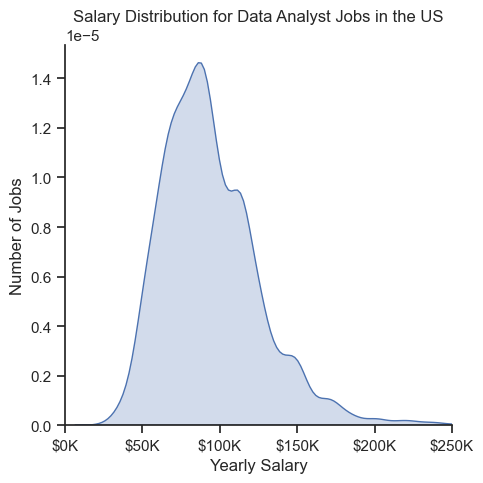

In [ ]:
#Histogram distribution salaries
from matplotlib.ticker import FuncFormatter
sns.set_theme(style='ticks')
sns.displot(df_DA_US['salary_year_avg'],kind='kde',fill=True)
plt.xlim(0,250000)
ax=plt.gca()
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${int(x/1000)}K')
)

plt.xlabel('Yearly Salary')
plt.ylabel('Number of Jobs')
plt.title('Salary Distribution for Data Analyst Jobs in the US')

plt.tight_layout()
plt.show()